Saving iris_dataset_200.csv to iris_dataset_200.csv
First 5 Rows:
   id  sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
0   1              5.7             3.0              4.2             1.2   
1   2              5.7             4.4              1.5             0.4   
2   3              4.8             3.1              1.6             0.2   
3   4              5.0             3.2              1.5             0.2   
4   5              6.4             2.8              5.6             2.1   

      species  
0  versicolor  
1      setosa  
2      setosa  
3      setosa  
4   virginica  

Dataset Shape:
(200, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               200 non-null    int64  
 1   sepal_length_cm  200 non-null    float64
 2   sepal_width_cm   200 non-null    float64
 3   p

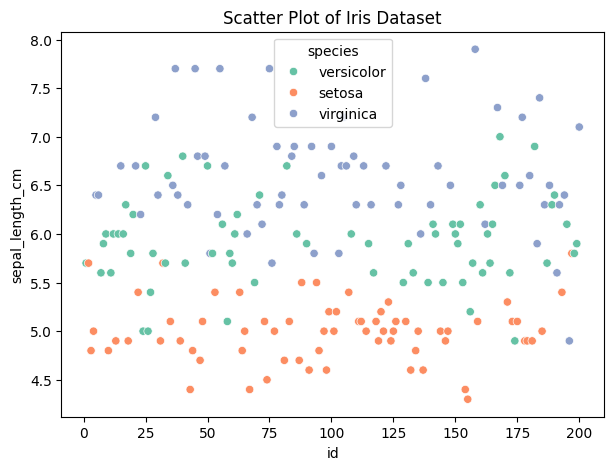

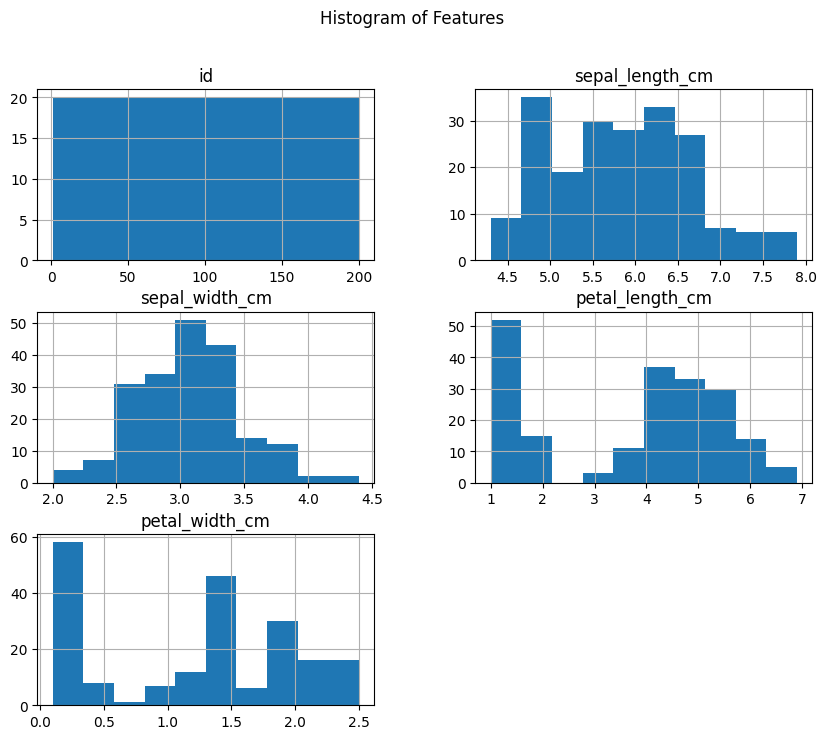


Training Data: (160, 5)
Testing Data: (40, 5)

========== Logistic Regression ==========



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:
0.975

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.93      0.96        14

    accuracy                           0.97        40
   macro avg       0.98      0.98      0.98        40
weighted avg       0.98      0.97      0.97        40



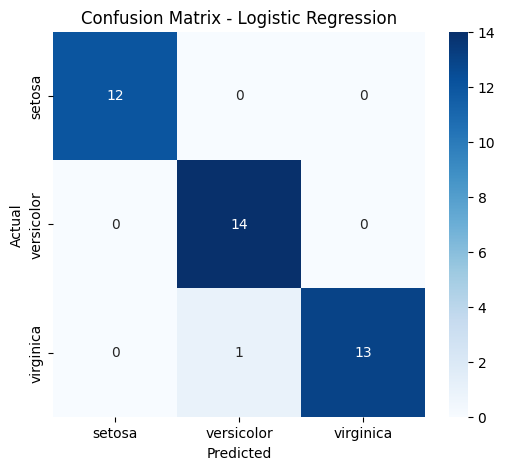


========== Decision Tree ==========

Accuracy:
0.95

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      1.00      0.93        14
           2       1.00      0.86      0.92        14

    accuracy                           0.95        40
   macro avg       0.96      0.95      0.95        40
weighted avg       0.96      0.95      0.95        40



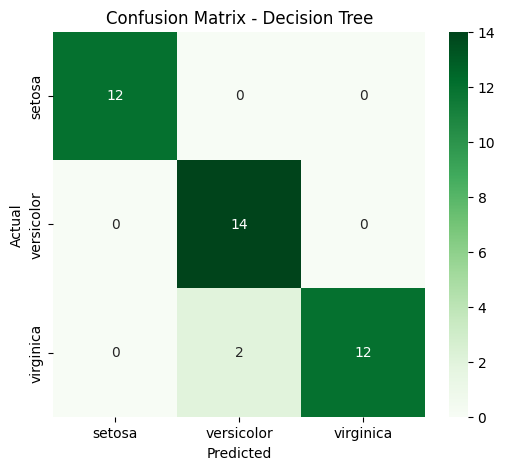


========== K-Nearest Neighbors ==========

Accuracy:
0.625

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.75      0.62        12
           1       0.57      0.57      0.57        14
           2       0.89      0.57      0.70        14

    accuracy                           0.62        40
   macro avg       0.66      0.63      0.63        40
weighted avg       0.67      0.62      0.63        40



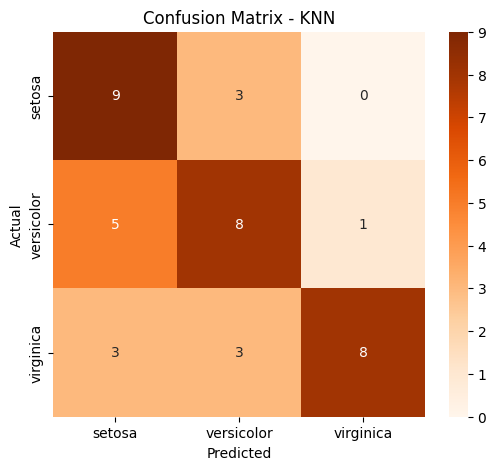


========== Model Comparison ==========

                 Model  Accuracy
0  Logistic Regression     0.975
1        Decision Tree     0.950
2  K-Nearest Neighbors     0.625


/tmp/ipykernel_1382/816969073.py:242: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


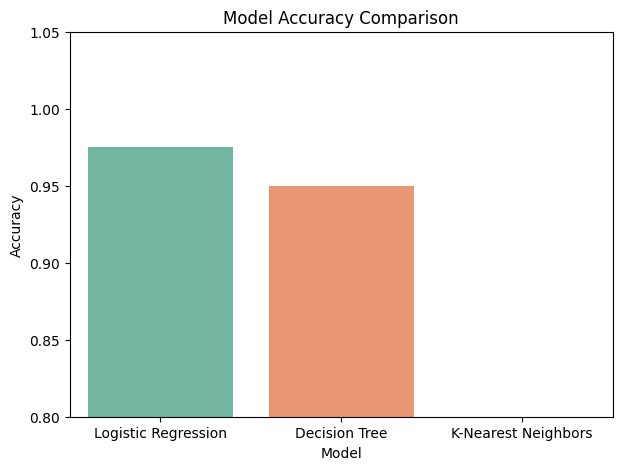

In [ ]:
# ==========================================================
# Iris Flower Classification using Machine Learning
# ==========================================================

# -------------------------------
# Step 1: Import Libraries
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------
# Step 2: Upload Dataset
# -------------------------------

uploaded = files.upload()

# Replace filename if different
df = pd.read_csv("iris_dataset_200.csv")

# -------------------------------
# Step 3: Display Dataset
# -------------------------------

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# -------------------------------
# Step 4: Data Visualization
# -------------------------------

# Scatter Plot

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x=df.columns[0],
    y=df.columns[1],
    hue=df.columns[-1],
    palette="Set2"
)

plt.title("Scatter Plot of Iris Dataset")
plt.show()

# Histogram

df.hist(figsize=(10,8))
plt.suptitle("Histogram of Features")
plt.show()

# -------------------------------
# Step 5: Prepare Dataset
# -------------------------------

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode target labels

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# -------------------------------
# Step 6: Split Dataset
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ==========================================================
# Logistic Regression Model
# ==========================================================

print("\n========== Logistic Regression ==========\n")

lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, lr_prediction))

print("\nClassification Report:")
print(classification_report(y_test, lr_prediction))

cm = confusion_matrix(y_test, lr_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# ==========================================================
# Decision Tree Model
# ==========================================================

print("\n========== Decision Tree ==========\n")

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, dt_prediction))

print("\nClassification Report:")
print(classification_report(y_test, dt_prediction))

cm = confusion_matrix(y_test, dt_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

# ==========================================================
# K-Nearest Neighbors Model
# ==========================================================

print("\n========== K-Nearest Neighbors ==========\n")

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

knn_prediction = knn_model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, knn_prediction))

print("\nClassification Report:")
print(classification_report(y_test, knn_prediction))

cm = confusion_matrix(y_test, knn_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

# ==========================================================
# Accuracy Comparison
# ==========================================================

lr_acc = accuracy_score(y_test, lr_prediction)
dt_acc = accuracy_score(y_test, dt_prediction)
knn_acc = accuracy_score(y_test, knn_prediction)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        knn_acc
    ]
})

print("\n========== Model Comparison ==========\n")
print(comparison)

# Accuracy Bar Chart

plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0.8,1.05)

plt.show()